# 🍿 Netflix Subscriber Churn Strategist
### *Advanced Behavioral Analysis & Retention Modeling*

This notebook explores the socio-economic and behavioral factors driving customer attrition at Netflix. Using a dataset of 5,000+ subscribers, we derive insights to optimize retention strategies.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Netflix Premium Aesthetic
NETFLIX_RED = '#E50914'
DARK_BG = '#141414'
TEXT_GRAY = '#E5E5E5'

sns.set_theme(style="dark", palette=[NETFLIX_RED, '#564d4d'])
plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor': DARK_BG,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': TEXT_GRAY,
    'xtick.color': TEXT_GRAY,
    'ytick.color': TEXT_GRAY,
    'text.color': TEXT_GRAY,
    'font.family': 'sans-serif',
    'grid.color': '#333333'
})

# Load dataset
df = pd.read_csv('../datasets/netflix_churn.csv')
print(f"Processing {len(df)} records...")

Processing 5000 records...


## 1. The Churn Heartbeat
An executive look at subscriber health.

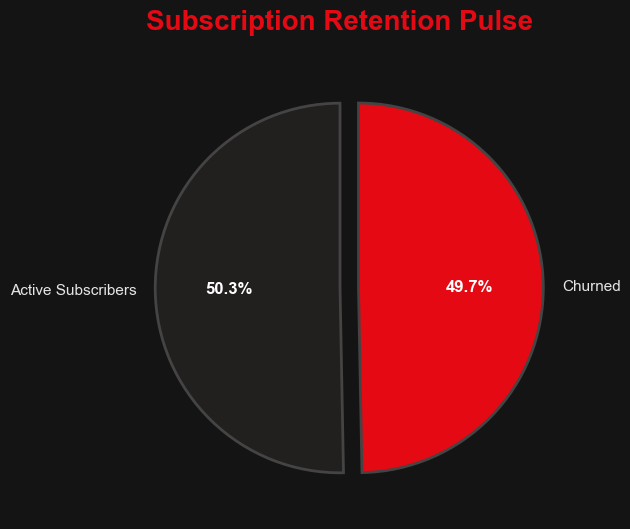

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
data = df['churned'].value_counts()
wedges, texts, autotexts = ax.pie(data, 
                                  labels=['Active Subscribers', 'Churned'], 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=['#221f1f', NETFLIX_RED],
                                  explode=(0, 0.1),
                                  wedgeprops={'edgecolor': '#444444', 'linewidth': 2})

plt.setp(autotexts, size=12, weight="bold", color="white")
plt.title('Subscription Retention Pulse', fontsize=20, color=NETFLIX_RED, pad=20, fontweight='black')
plt.show()

## 2. Demographic Depth
How does age and gender influence loyalty?

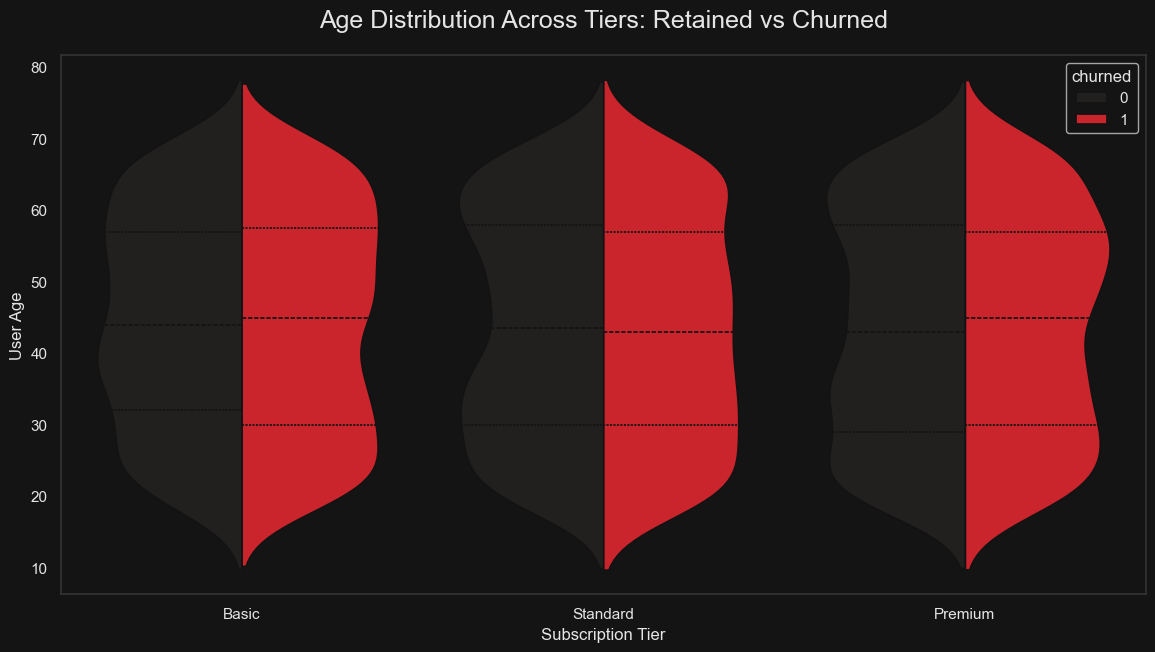

In [10]:
plt.figure(figsize=(14, 7))
sns.violinplot(data=df, x='subscription_type', y='age', hue='churned', 
               split=True, inner="quart", palette={0: '#221f1f', 1: NETFLIX_RED})
plt.title('Age Distribution Across Tiers: Retained vs Churned', fontsize=18, pad=20)
plt.ylabel('User Age', fontsize=12)
plt.xlabel('Subscription Tier', fontsize=12)
plt.show()

## 3. Engagement Velocity
Does watch time prevent churn?

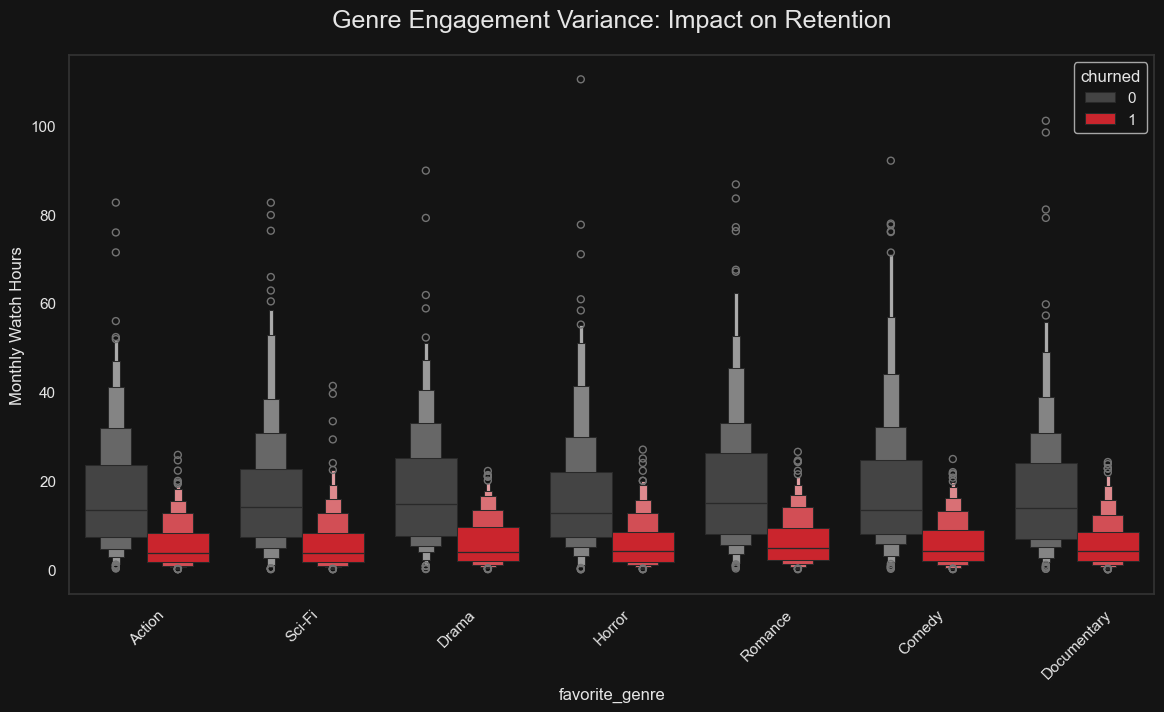

In [11]:
plt.figure(figsize=(14, 7))
sns.boxenplot(data=df, x='favorite_genre', y='watch_hours', hue='churned', 
              palette={0: '#444444', 1: NETFLIX_RED})
plt.title('Genre Engagement Variance: Impact on Retention', fontsize=18, pad=20)
plt.ylabel('Monthly Watch Hours', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## 4. Payment Friction
Correlation between payment methods and churn probability.

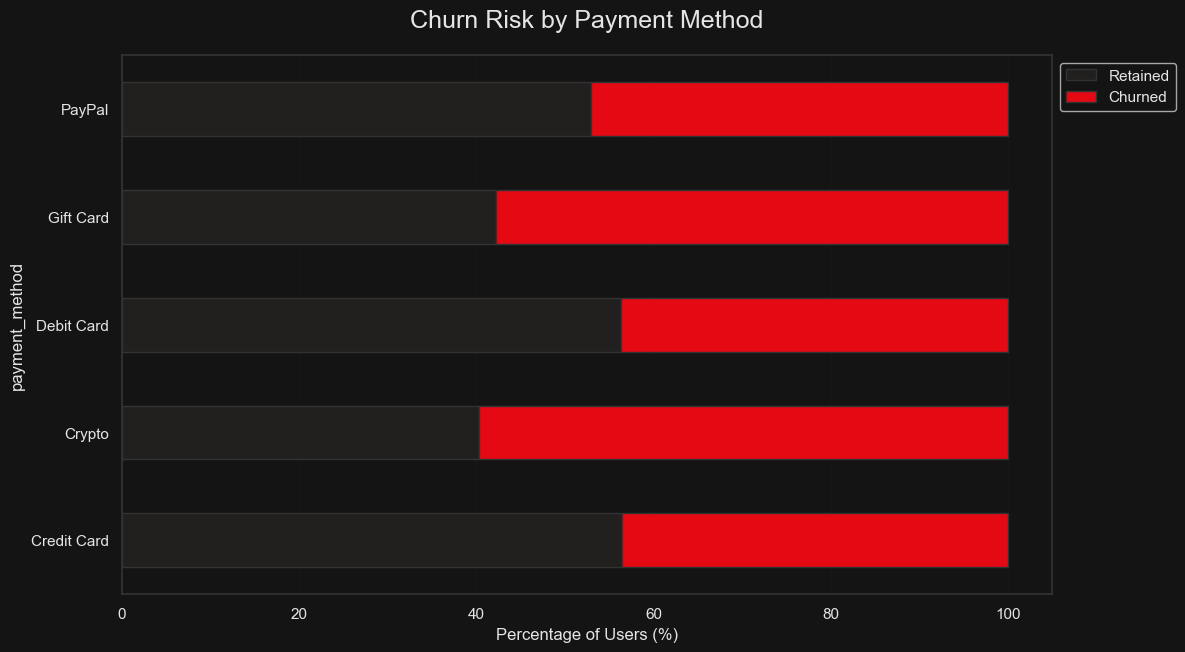

In [12]:
pm_churn = pd.crosstab(df['payment_method'], df['churned'], normalize='index') * 100
pm_churn.plot(kind='barh', stacked=True, color=['#221f1f', NETFLIX_RED], figsize=(12, 7), edgecolor='#333333')
plt.title('Churn Risk by Payment Method', fontsize=18, pad=20)
plt.xlabel('Percentage of Users (%)', fontsize=12)
plt.legend(['Retained', 'Churned'], bbox_to_anchor=(1, 1))
plt.grid(axis='x', alpha=0.1)
plt.show()

## 5. Regional Loyalty Map
Which markets are most volatile?

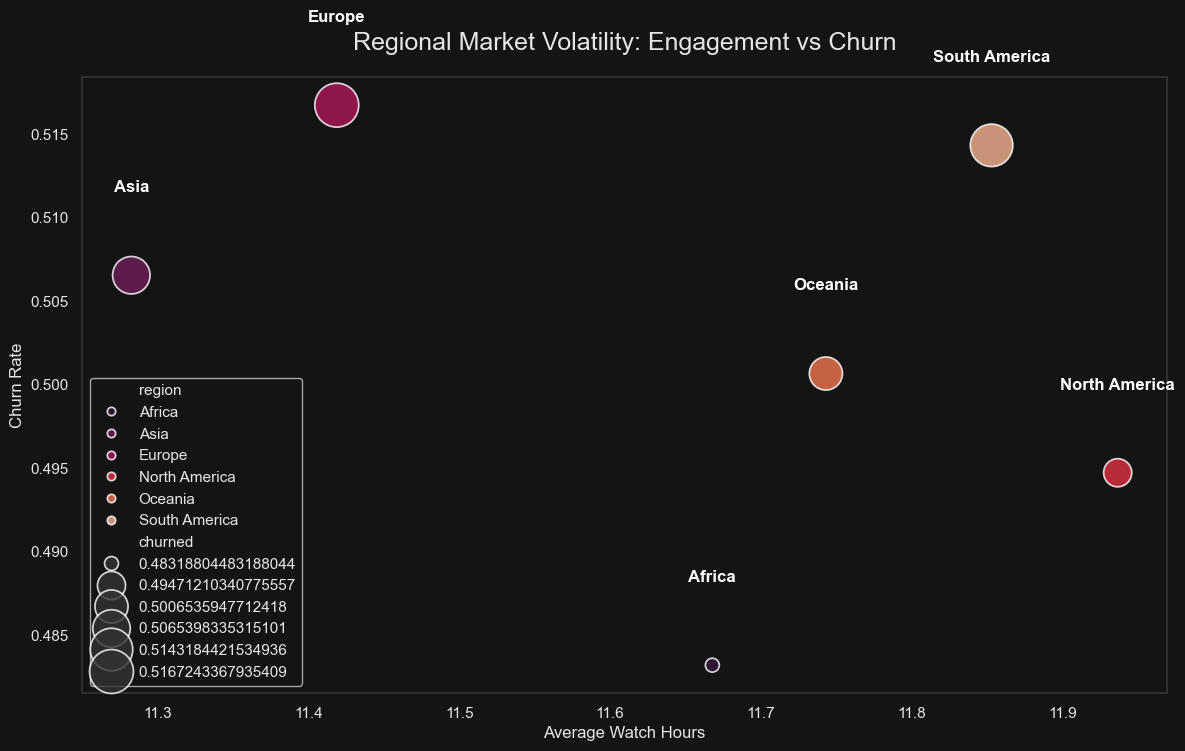

In [13]:
plt.figure(figsize=(14, 8))
region_metrics = df.groupby('region').agg({'churned': 'mean', 'watch_hours': 'mean'}).reset_index()
sns.scatterplot(data=region_metrics, x='watch_hours', y='churned', 
                size='churned', sizes=(100, 1000), hue='region', palette='rocket', alpha=0.8)

for i in range(region_metrics.shape[0]):
    plt.text(region_metrics.watch_hours[i], region_metrics.churned[i]+0.005, 
             region_metrics.region[i], horizontalalignment='center', weight='bold', color='white')

plt.title('Regional Market Volatility: Engagement vs Churn', fontsize=18, pad=20)
plt.ylabel('Churn Rate', fontsize=12)
plt.xlabel('Average Watch Hours', fontsize=12)
plt.show()